<a href="https://colab.research.google.com/github/chiarasabatino35-debug/ritratti-di-donne/blob/main/Copia_di_DHDMCH_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Humanities e Data Management / Informatica per i Beni Culturali (2025/2026)

TITOLO:
**RITRATTI DI DONNE**

## 1. Introduzione

Il mondo della storia dell'arte è, da sempre, dominato da figure maschili: da Giotto a Picasso, da Botticelli a De Chirico, da Raffaello a Pollock, da Rubens a Van Gogh e altri centinaia di migliaia di nomi. Il ruolo femminile sembra essere rilegato a quello della cosiddetta "musa ispiratrice". Eppure, non poche sono le artiste che hanno saputo distringuersi nel panorama storico-artistico, nonostante le convenzioni sociali che impedivano loro di esprimersi al 100%.

### 1.1. Obiettivi

L'obiettivo di questo progetto è mettere in evidenza, oltre al "gender gap", come le restrizioni sociali abbiano influenzato la produzione artistica femminile. E' vero che le donne realizzavano principalmente ritratti e autoritratti? E', forse, anche vero che questa "distinzione sociale" si riflette anche sulla collocazione delle loro opere? E' a queste domande che il progetto "Ritratti di donne" intende dare una risposta.  

### 1.2. Dati utilizzati

I dati di input utilizzati sono stati presi da un file CSV ("https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv") di 229.3+ KB.
I dati di output consistono in questo notebook, comprendente testo e codice per l'analisi dei dati.

### 1.3. Documentazione

| Variabile | Tipo | Definizione | Esempio |
| :--- | :--- | :--- | :--- |
| **id** | int64 | Identificativo univoco dell'opera. | 1, 2, 3 |
| **titoli** | object | Nome dell'opera o del manufatto. | *Portrait of a Lady* |
| **artisti** | object | Genere dell'autore (usato per il filtro). | femmina, maschio |
| **generi** | object | Categoria artistica (es. ritratto). | ritratto, paesaggio |
| **museo** | object | Luogo di conservazione dell'opera. | Museu Nacional |
| **tecnica** | object | Materiali e metodo di realizzazione. | olio su tela |
| **anno** | float64 | Anno di creazione dell'opera. | 1850.0 |
### 1.4. Organizzazione

I dati di output verrano lavorati su Google Colab.

### 1.5. Preservazione

I dati di output saranno conservati nella repository Github di Chiara Sabatino.

### 1.6. Accesso e Utilizzo

I dati di output sono rilasciati sotto licenza CCO 1.0 Universal.

La prima cosa che andiamo a fare è importare Pandas, insieme al Dataframe che andremo ad esplorare.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv ("https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv")

Diamo un'occhiata al nostro dataframe.

In [3]:
df.shape

(2444, 12)

In [4]:
df.columns

Index(['id', 'titolo', 'artisti', 'data_creazione', 'generi', 'luoghi',
       'collezioni', 'contenuti', 'movimenti', 'soggetti', 'altezza',
       'larghezza'],
      dtype='object')

In [5]:
df.head()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0


In [6]:
df.tail()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Palazzo Frizzoni,Accademia Carrara; Palazzo Frizzoni,Antonio Agliardi,NaN,Antonio Agliardi,140.0,112.0
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,chiesa di Santa Maria in Fontibus,chiesa di Santa Maria in Fontibus,Benedetto Revelli,NaN,Benedetto Revelli,220.0,150.0
2443,http://www.wikidata.org/entity/Q137169658,"Ritratto di fanciulla, ""Violante""",Giovanni Cariani (maschio),1600,ritratto,Galleria Estense,Galleria Estense,parapetto; donna giovane,pittura veneta; Alto Rinascimento,donna giovane,90.0,65.0


A questo punto, vedendo qualche valore nullo nelle righe soprastanti, mi sono chiesta quanti fossero i valori nulli, presenti nel dataframe, per ogni colonna.

In [7]:
print(df.isnull().sum())

id                   0
titolo               0
artisti            285
data_creazione     966
generi             920
luoghi              82
collezioni         208
contenuti          423
movimenti         2062
soggetti           778
altezza           1163
larghezza         1175
dtype: int64


Il mio progetto parte da una domanda semplice: qual è il genere più diffuso? A questo punto, prima di procedere, voglio riempire tutte le celle della colonna "generi" riportanti un valore nullo con "Genere ignoto". Questo mi ha aiutato, non solo a vedere quante opere mancano di un genere specifico, ma anche a risolvere il problema dei valori nulli presenti nella mia colonna di interesse.

In [45]:
df["generi"] = df["generi"].fillna("Genere ignoto")

"Nudo artistico; pittura mitologica", "ritratto; ritratto di gruppo", "allegoria; pittura mitologica". Questi sono solo alcuni esempi di generi che compaiono nella stessa cella di una stessa riga. Tuttavia, se queste stringhe non vengono separate, Pandas riconosce "nudo artistico; pittura mitologica" come un nuovo genere diverso dagli altri, contandolo singolarmente. Per rispondere alla mia prima domanda, devo basarmi su quante volte un genere appare e non su quanti "nuovi generi" esistono nel dataframe.

In [9]:
generi_separati = df["generi"].str.split(";").explode().str.strip()

E allora, qual è il genere più diffuso?

In [10]:
classifica_generi = generi_separati.value_counts()
print(classifica_generi)

generi
Genere ignoto            920
arte religiosa           821
ritratto                 441
pittura mitologica        75
arte di genere            53
autoritratto              42
nudo artistico            23
pittura storica           21
pittura paesaggistica     19
allegoria                 19
paesaggio urbano          17
vedutismo                 10
natura morta               8
paesaggio marino           4
ritratto di gruppo         3
portrait historié          3
capriccio                  3
ritratto equestre          3
dipinti di battaglie       2
pittura floreale           2
purismo                    1
pastorale                  1
aeropittura                1
neoclassicismo             1
miniatura                  1
distintivo araldico        1
ritratto doppio            1
Narrative art              1
Name: count, dtype: int64


La mia curiosità non si ferma e quindi decido di voler vedere, su un grafico a barre orizzontali, la differenza di diffusione dei primi 10 generi più presenti nel dataframe. Questo mi permette di avere una visione decisamente più d'impatto e più ordinata.

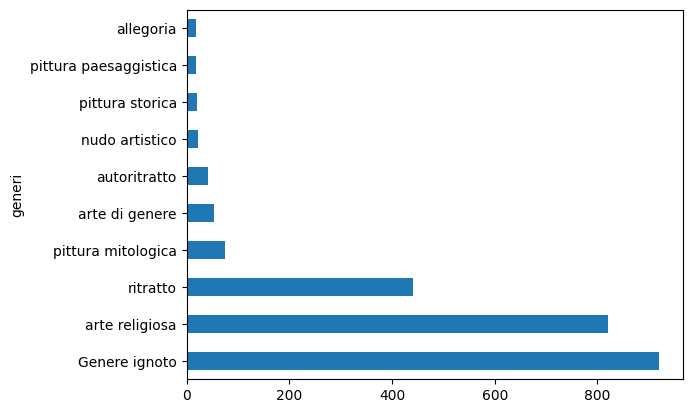

In [11]:
top_generi = classifica_generi.head(10).plot.barh()

Si ma, le donne? "Ritratti di donne" è un progetto che si pone, inizialmente, una semplice domanda: quante sono le artiste donne presenti nel nostro dataframe?

In [12]:
conteggio_donne = df["artisti"].str.contains("femmina", na=False).sum()
print(conteggio_donne)

36


2444 righe. 36 donne. Dal punto di vista storico-artistico, è risaputo che la presenza delle donne nel mondo dell'arte è ristretta. O forse è quello che ci hanno sempre raccontato? Perchè si parla sempre poco di Artemisia Gentileschi, la prima donna che riesce a superare un'epoca maschilista affermando il suo successo internazionale nel Barocco? O Ancora Rosalba Carriera, colei che introduce i ritratti a pastello nel mondo dell'arte; Frida Kahlo, icona del XX secolo; Marina Abramovic, "madrina della performance art". Tantissime donne sono riuscite ad affermarsi nel mondo dell'arte, ma è forse vero che la loro produzione artistica si concentrava principalmente sui ritratti e autoritratti?

In [13]:
df_donne = df[df["artisti"].str.contains("femmina", na=False)]
print(df_donne[["artisti", "generi"]])

                                                artisti  \
6                       Artemisia Gentileschi (femmina)   
346                           Lavinia Fontana (femmina)   
350                   Élisabeth Vigée Le Brun (femmina)   
398                         Ginevra Cantofoli (femmina)   
405                           Lavinia Fontana (femmina)   
406                              Fede Galizia (femmina)   
408                     Artemisia Gentileschi (femmina)   
424   Onofrio Palumbo (maschio); Artemisia Gentilesc...   
436                           Plautilla Nelli (femmina)   
472                         Elisabeth Chaplin (femmina)   
508                           Vittoria Ligari (femmina)   
596                        Henriette Lorimier (femmina)   
616                  Jeanne-Elisabeth Chaudet (femmina)   
629   Antoine Cécile Hortense Haudebourt-Lescot (fem...   
683                  Marie-Guillemine Benoist (femmina)   
684                  Marie-Guillemine Benoist (femmina) 

A causa delle convenzioni sociali, alle donne era vietato frequentare accademie d'arte e studiare il "nudo artistico". Il ritratto era ritenuto il genere più adatto alla "sensibilità" femminile, ma anche un "genere minore" da rilegare principalmente alle donne, ritenute incapaci di dipingere temi complessi, come la pittura storica o religiosa. Al tempo stesso, l'autoritratto serviva loro per affermare la propria identità e la loro posizione sociale come artiste.

In [14]:
conteggio_ritratti_d = df_donne["generi"].str.contains("ritratto|autoritratto", case=False).sum()
print(conteggio_ritratti_d)

20


A questo punto, escludendo le donne e gli artisti che presentano un valore nullo nella cella di riferimento, quanti sono gli uomini presenti nel dataframe?.

In [15]:
conteggio_maschi = df["artisti"].str.contains("maschio", na=False).sum()
print(conteggio_maschi)

2124


Quanti saranno i ritratti o gli autoritratti associati ad artisti maschi?.

In [16]:
df_maschi = df[df["artisti"].str.contains("maschio", na=False)]
conteggio_ritratti_m = df_maschi[df_maschi["generi"]!="Genere ignoto"]["generi"].str.contains("ritratto|autoritratto", na=False).sum()
print(conteggio_ritratti_m)

394


394 contro 20 è decisamente un numero altissimo. Questo dato, però, può essere fuorviante. Ma se dovessimo parlare di percentuali?.

In [17]:
perc_femminile = conteggio_ritratti_d/conteggio_donne*100
perc_maschile = conteggio_ritratti_m/conteggio_maschi*100
print(perc_femminile)
print(perc_maschile)

55.55555555555556
18.54990583804143


Sebbene il numero dei ritratti e autoritratti realizzati da uomini sia numericamente superiore, la percentuale ci dice una cosa totalmente diversa: la ritrattistica assorbe quasi tre quarti della produzione femminile presa in esame, in confronto a quella maschile che non arriva neanche ad un 20%.

<Axes: title={'center': 'Proporzione di ritratti e autoritratti tra le opere di artiste donne'}>

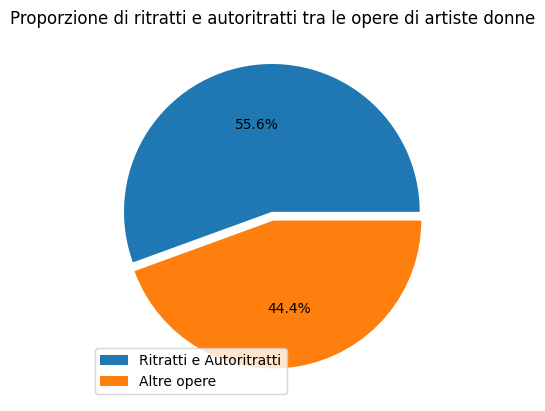

In [18]:
grafico_donne = pd.Series([conteggio_ritratti_d, conteggio_donne-conteggio_ritratti_d], index=["Ritratti e Autoritratti", "Altre opere"])
grafico_donne.plot.pie(autopct="%1.1f%%", title = "Proporzione di ritratti e autoritratti tra le opere di artiste donne",legend=True, ylabel="", explode=[0.03, 0.03], labeldistance=None)

<Axes: title={'center': 'Proporzione di ritratti e autoritratti tra le opere di artisti maschi'}>

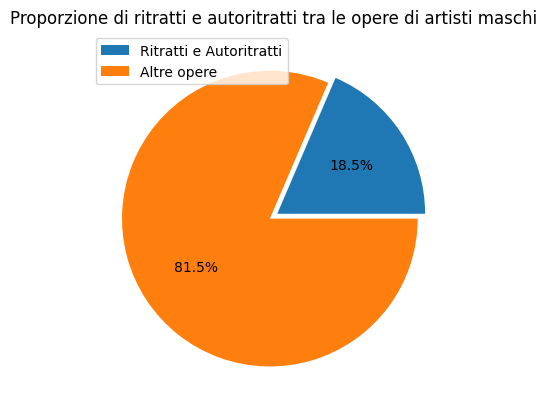

In [19]:
grafico_maschi = pd.Series([conteggio_ritratti_m, conteggio_maschi - conteggio_ritratti_m], index=["Ritratti e Autoritratti", "Altre opere"])
grafico_maschi.plot.pie(autopct="%1.1f%%", title = "Proporzione di ritratti e autoritratti tra le opere di artisti maschi", legend=True, ylabel= "", explode=[0.03, 0.03], labeldistance=None)

Il grafico a torta mi ha permesso di avere un'idea molto chiara della differenza di percentuali.
Tuttavia, è un confronto equo quello tra 36 donne e 2124 uomini?. E se prendessi in considerazione un campione di 36 uomini casuali?.

In [20]:
print(df_maschi[["artisti", "generi"]].sample(n=36, random_state=10))

                                                artisti  \
1841                    Domenico Maria Canuti (maschio)   
1339                             Jan Provoost (maschio)   
2023                     Gianfilippo Usellini (maschio)   
1629                        Jacopo Tintoretto (maschio)   
399                           Agnolo Bronzino (maschio)   
176                   Jan Brueghel il Vecchio (maschio)   
1892                        Tommaso da Modena (maschio)   
1756                         Lazzaro Bastiani (maschio)   
1649                           Guido da Siena (maschio)   
1901                       Domenico Beccafumi (maschio)   
99                                 Caravaggio (maschio)   
71                                 Caravaggio (maschio)   
829                                Italo Josz (maschio)   
922                            Domenico Piola (maschio)   
882                              Taddeo Gaddi (maschio)   
2400                            Oscar Sorgato (maschio) 

In [21]:
df_maschi_36 = df_maschi.sample(n=36, random_state=10)

Quanti sono i ritratti e gli autoritratti presenti in questo dataframe di 36 uomini scelti casualmente?.

In [22]:
conteggio_ritratti_m_36 = df_maschi_36["generi"].str.contains("ritratto|autoritratto", case=False).sum()
print(conteggio_ritratti_m_36)

6


In [23]:
opere_m_36 = len(df_maschi_36)
print(opere_m_36)

36


Per togliermi ogni dubbio decido di calcolare nuovamente la percentuale, questa volta su un campione casuale di 36 artisti.

In [24]:
nuova_perc_m = conteggio_ritratti_m_36/opere_m_36*100
print(nuova_perc_m)

16.666666666666664


<Axes: title={'center': 'Proporzione di ritratti e autoritratti tra le opere di 36 artisti maschi casuali'}>

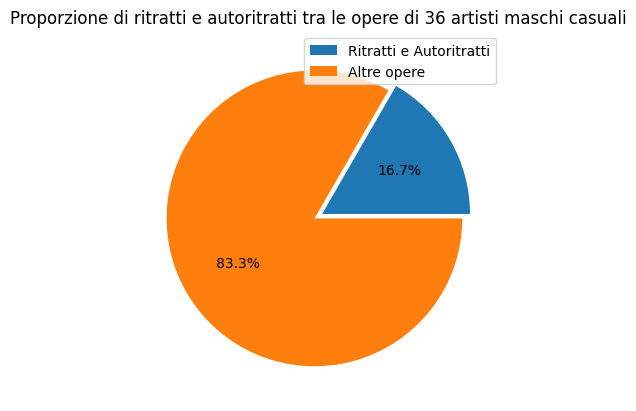

In [25]:
nuovo_grafico_m = pd.Series([conteggio_ritratti_m_36, opere_m_36-conteggio_ritratti_m_36], index=["Ritratti e Autoritratti", "Altre opere"])
nuovo_grafico_m.plot.pie(autopct="%1.1f%%", title="Proporzione di ritratti e autoritratti tra le opere di 36 artisti maschi casuali", legend=True, ylabel= "", explode=[0.03, 0.03], labeldistance=None)

Ancora una volta, ho la conferma della mia tesi: la produzione artistica femminile viene occupata per più della metà dal genere del ritratto e autoritratto; mentre quella maschile è decisamente più variegata.

Arrivati a questo punto, sorge un dubbio: e se questa differenza, se queste restrizioni sociali abbiano influenzato anche la collocazione delle opere femminili? Mi spiego meglio: è probabile che in un museo più "conosciuto" e "importante" ci sia una prevalenza di opere maschili, mentre in un museo più piccolo prevalgano opere femminili?.
La prima cosa che faccio è andare a riempire le celle con valore nullo, relative alla colonna "luoghi" con "luogo ignoto" in modo tale che questo non influenzi la mia ricerca.

In [26]:
df["luoghi"] = df["luoghi"].fillna("luogo ignoto")

Ora, dal dataframe precentemente creato e relativo solamente alle donne, calcolo tutti i valori relativi alla colonna "luoghi".

In [27]:
musei_donne = df_donne["luoghi"].value_counts()
print(musei_donne)

luoghi
Milano                                               3
sala 2.4 della Pinacoteca Civica di palazzo Volpi    3
Ca' Rezzonico                                        3
Palazzo degli Uffizi                                 2
Galleria d'arte moderna di Firenze                   2
Pinacoteca Nazionale di Bologna                      2
Gallerie dell'Accademia                              2
Firenze                                              2
Ferrara                                              2
Italia                                               1
Museo di San Marco                                   1
Galleria nazionale d'arte antica                     1
Palazzo Pitti                                        1
Corridoio Vasariano                                  1
Pinacoteca Ambrosiana                                1
Museo Mario Praz                                     1
deposito del museo                                   1
Museo napoleonico di Roma                            1
Mus

<Axes: ylabel='count'>

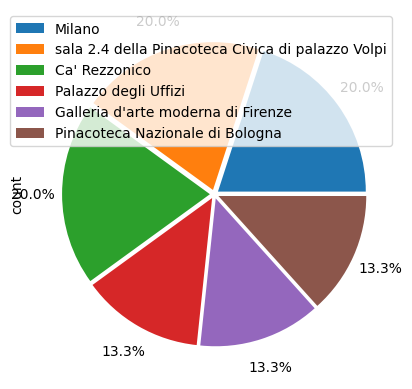

In [28]:
df_donne["luoghi"].value_counts().head(6).plot.pie(autopct="%1.1f%%", pctdistance=1.20, legend=True, explode=[0.03, 0.03, 0.03, 0.03, 0.03, 0.03], labeldistance=None)

Faccio la stessa cosa, ma con il dataframe relativo a TUTTI gli artisti maschi.

In [29]:
musei_maschi = df_maschi["luoghi"].value_counts()
print(musei_maschi)

luoghi
Palazzo degli Uffizi                               110
Pinacoteca Nazionale di Bologna                     54
Galleria all'aperto dell'affresco di Arcumeggia     42
Palazzo Cini                                        35
Gallerie dell'Accademia                             34
                                                  ... 
Museo Civico di Bassano                              1
chiesa di San Rocco                                  1
Complesso di Santa Caterina                          1
chiesa di San Giovanni a Carbonara                   1
duomo di Livorno                                     1
Name: count, Length: 591, dtype: int64


Sicuramente vediamo una maggiore diffusione delle opere maschili ma questo anche perchè, oggettivamente, stiamo prendendo in esame un numero (2124) decisamente più grande rispetto a 36 donne. Quindi, ho pensato di fare lo stesso ragionamento di prima, riprendendo il dataframe dei 36 artisti maschi casuali.

In [30]:
musei_maschi_36 = df_maschi_36["luoghi"].value_counts()
print(musei_maschi_36)

luoghi
Galleria all'aperto dell'affresco di Arcumeggia       3
Palazzo Cini                                          3
palazzo Bianco                                        2
Palazzo degli Uffizi                                  2
Scuola Grande di San Rocco                            1
Galleria nazionale d'arte antica                      1
Musei civici di Treviso                               1
Museo Correr                                          1
Pinacoteca nazionale di Siena                         1
Quadreria di Casa Martelli                            1
Galleria Doria Pamphilj                               1
Collezioni d'arte della Fondazione Cariplo            1
Palazzo Pepoli Campogrande                            1
Museo d'arte di Palazzo Gavotti                       1
Museo civico di Modena                                1
santuario di Nostra Signora della Misericordia        1
basilica di Santo Spirito; cappella Bini-Capponi      1
Galleria Nazionale d'Arte Moderna e Conte

<Axes: ylabel='count'>

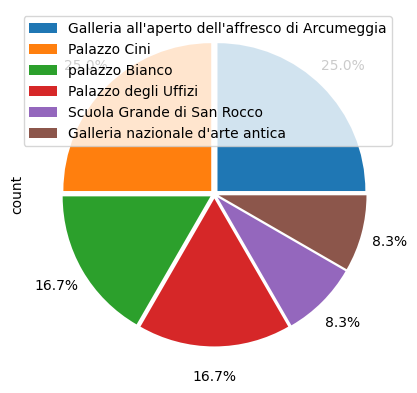

In [31]:
df_maschi_36["luoghi"].value_counts().head(6).plot.pie(autopct="%1.1f%%", pctdistance=1.20, legend=True, explode=[0.03, 0.03, 0.03, 0.03, 0.03, 0.03], labeldistance=None)

## 4. Conclusione
2124 uomini contro 36 donne in un dataframe di 2444 righe non è un caso. I dati analizzati riportano quello che è un sistema di esclusione che va avanti da tempo. Abbiamo avuto la conferma che le donne, per diverse ragioni, erano confinate nel genere del ritratto e dell'autoritratto; mentre la produzione maschile è decisamente più varia. Tuttavia, questa forma di esclusione sembra non coinvolgere il "luogo" nel quale le opere si trovano. Questo dimostra che, nonostante tutto, il valore storico-artistico delle opere realizzate da artiste donne è stato riconosciuto da importanti istituzioni culturali.